### Goal 1

This notebook tries to answer wether NonLimber is important for cosmic shear and galaxy-galaxy lensing for Roman

In [1]:
import numpy as np
import pytest
import pyccl as ccl
from pyccl import CCLWarning

from pyccl.pk2d import Pk2D
from pyccl.correlations import correlation,correlation_binned

In [2]:
#load covariance matrix, source and lens sample for DES Y3
cov_file    = './cocoa/Cocoa/projects/roman_real/data/cov_roman'
source_file = './cocoa/Cocoa/projects/roman_real/data/fiducial.nz'
lens_file   = './cocoa/Cocoa/projects/roman_real/data/lsst_lens_4cosmolike.nz'

cov_raw = np.loadtxt(cov_file)
ncov = int(np.max(cov_raw[:,0]))+1
cov = np.zeros((ncov, ncov))
for i in range(len(cov_raw)):
    ii = int(cov_raw[i, 0])
    jj = int(cov_raw[i, 1])
    element = cov_raw[i,8] + cov_raw[i,9]
    cov[ii,jj] = element
    cov[jj,ii] = element

srcs_nzs = np.loadtxt(source_file)
lens_nzs = np.loadtxt(lens_file)

z_srcs = srcs_nzs[:,0] + 0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0] + 0.005
lens_nz = lens_nzs[:,1:]

nsrcs = srcs_nz.shape[1]
nlens = lens_nz.shape[1]
ntheta = int(ncov/(nsrcs*(nsrcs+1)+nsrcs*nlens+nlens))

starts = [0, int(nsrcs*(nsrcs+1)*ntheta), int((nsrcs*(nsrcs+1)+nsrcs*nlens)*ntheta), int((nsrcs*(nsrcs+1)+nsrcs*nlens+nlens)*ntheta)]
cov_xi     = cov[starts[0]:starts[1],:][:,starts[0]:starts[1]]
cov_gammat = cov[starts[1]:starts[2],:][:,starts[1]:starts[2]]
cov_wtheta = cov[starts[2]:starts[3],:][:,starts[2]:starts[3]]
invcov_xi     = np.linalg.pinv(cov_xi)
invcov_gammat = np.linalg.pinv(cov_gammat)
invcov_wtheta = np.linalg.pinv(cov_wtheta)

COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

### Limber

In [3]:
# setup lens and source tracer
srcs = []
lens = []
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=False, n_samples=400))

#calculate the power spectrum for calculation of correlation function
ELLMAX_NOLIMBER = 150
logLMIN = np.log(ELLMAX_NOLIMBER)
logLMAX = np.log(60000+1)
NCell = 300
dlogL = (logLMAX - logLMIN)/(NCell - 1)

ells = np.zeros(ELLMAX_NOLIMBER+NCell)
for i in range(ELLMAX_NOLIMBER):
    ells[i] = i
for i in range(NCell):
    ells[i+ELLMAX_NOLIMBER] = np.exp(logLMIN + dlogL*i)
ells = ells[1:]

xi_cl     = []
gammat_cl = []
wtheta_cl = []

for i in range(nsrcs):
    for j in range(i,nsrcs):
        xi_cl.append(ccl.angular_cl(COSMO, srcs[i], srcs[j], ells, l_limber=-1) )

for i in range(nlens):
    for j in range(nsrcs):
        gammat_cl.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, l_limber=-1) )
        
for i in range(nlens):
    wtheta_cl.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, l_limber=-1))
    
#calculate the correlation function
tmin = 1.
tmax = 500.

logtmin = np.log(tmin)
logtmax = np.log(tmax)
logdt=(logtmax - logtmin)/ntheta
fac = (2./3.)
thetas = np.zeros(ntheta)

for i in range(ntheta):
    thetamin = np.exp(logtmin + (i + 0.)*logdt)
    thetamax = np.exp(logtmin + (i + 1.)*logdt)
    thetas[i] = fac * (thetamax**3 - thetamin**3) / (thetamax*thetamax    - thetamin*thetamin)
thetas /= 60

theta_b  = np.geomspace(tmin, tmax, ntheta+1) / 60
theta_u  = theta_b[1:]
theta_l  = theta_b[:-1]

ncombo_xi     = int(nsrcs*(nsrcs+1))
ncombo_gammat = int(nsrcs*nlens)
ncombo_wtheta = int(nlens)

xi, gammat, wtheta = [],[],[]

for i in range(ncombo_xi//2):
    xi.append(correlation_binned(COSMO, ell=ells, C_ell=xi_cl[i], theta_min=theta_l, theta_max=theta_u, type='GG+', method='Legendre'))
for i in range(ncombo_xi//2):
    xi.append(correlation_binned(COSMO, ell=ells, C_ell=xi_cl[i], theta_min=theta_l, theta_max=theta_u, type='GG-', method='Legendre'))
xi = np.concatenate(xi)

for i in range(ncombo_gammat):
    gammat.append(correlation_binned(COSMO, ell=ells, C_ell=gammat_cl[i], theta_min=theta_l, theta_max=theta_u, type='NG', method='Legendre'))
gammat = np.concatenate(gammat)

for i in range(ncombo_wtheta):
    wtheta.append(correlation_binned(COSMO, ell=ells, C_ell=wtheta_cl[i], theta_min=theta_l, theta_max=theta_u, type='NN', method='Legendre'))
wtheta = np.concatenate(wtheta)

limber_noRSD_xi     = xi
limber_noRSD_gammat = gammat
limber_noRSD_wtheta = wtheta

### NoLimber

In [4]:
# setup lens and source tracer
srcs = []
lens = []
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=False, n_samples=400))

#calculate the power spectrum for calculation of correlation function
ELLMAXS = [150, 300, 600, 1200, 2400, 4000]
chi2s = [[],[],[]]
for ELLMAX_NOLIMBER in ELLMAXS:
    #ELLMAX_NOLIMBER = 150
    logLMIN = np.log(ELLMAX_NOLIMBER)
    logLMAX = np.log(60000+1)
    NCell = 300
    dlogL = (logLMAX - logLMIN)/(NCell - 1)
    
    ells = np.zeros(ELLMAX_NOLIMBER+NCell)
    for i in range(ELLMAX_NOLIMBER):
        ells[i] = i
    for i in range(NCell):
        ells[i+ELLMAX_NOLIMBER] = np.exp(logLMIN + dlogL*i)
    ells = ells[1:]
    
    xi_cl     = []
    gammat_cl = []
    wtheta_cl = []
    
    for i in range(nsrcs):
        for j in range(i,nsrcs):
            xi_cl.append(ccl.angular_cl(COSMO, srcs[i], srcs[j], ells, l_limber=ELLMAX_NOLIMBER) )
    
    for i in range(nlens):
        for j in range(nsrcs):
            gammat_cl.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, l_limber=ELLMAX_NOLIMBER) )
            
    for i in range(nlens):
        wtheta_cl.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, l_limber=ELLMAX_NOLIMBER))
        
    #calculate the correlation function
    tmin = 1.
    tmax = 500.
    
    logtmin = np.log(tmin)
    logtmax = np.log(tmax)
    logdt=(logtmax - logtmin)/ntheta
    fac = (2./3.)
    thetas = np.zeros(ntheta)
    
    for i in range(ntheta):
        thetamin = np.exp(logtmin + (i + 0.)*logdt)
        thetamax = np.exp(logtmin + (i + 1.)*logdt)
        thetas[i] = fac * (thetamax**3 - thetamin**3) / (thetamax*thetamax    - thetamin*thetamin)
    thetas /= 60
    
    theta_b  = np.geomspace(tmin, tmax, ntheta+1) / 60
    theta_u  = theta_b[1:]
    theta_l  = theta_b[:-1]
    
    ncombo_xi     = int(nsrcs*(nsrcs+1))
    ncombo_gammat = int(nsrcs*nlens)
    ncombo_wtheta = int(nlens)
    
    xi, gammat, wtheta = [],[],[]
    
    for i in range(ncombo_xi//2):
        xi.append(correlation_binned(COSMO, ell=ells, C_ell=xi_cl[i], theta_min=theta_l, theta_max=theta_u, type='GG+', method='Legendre'))
    for i in range(ncombo_xi//2):
        xi.append(correlation_binned(COSMO, ell=ells, C_ell=xi_cl[i], theta_min=theta_l, theta_max=theta_u, type='GG-', method='Legendre'))
    xi = np.concatenate(xi)
    
    for i in range(ncombo_gammat):
        gammat.append(correlation_binned(COSMO, ell=ells, C_ell=gammat_cl[i], theta_min=theta_l, theta_max=theta_u, type='NG', method='Legendre'))
    gammat = np.concatenate(gammat)
    
    for i in range(ncombo_wtheta):
        wtheta.append(correlation_binned(COSMO, ell=ells, C_ell=wtheta_cl[i], theta_min=theta_l, theta_max=theta_u, type='NN', method='Legendre'))
    wtheta = np.concatenate(wtheta)
    
    nolimber_noRSD_xi     = xi
    nolimber_noRSD_gammat = gammat
    nolimber_noRSD_wtheta = wtheta

    print('just pure density kernel')
    chi2_xi     = (limber_noRSD_xi - nolimber_noRSD_xi)@invcov_xi@(limber_noRSD_xi - nolimber_noRSD_xi)
    chi2s[0].append(chi2_xi)
    print(f'The Limber raises chi2 {chi2_xi:.2f} for xi')
    chi2_gammat = (limber_noRSD_gammat - nolimber_noRSD_gammat)@invcov_gammat@(limber_noRSD_gammat - nolimber_noRSD_gammat)
    print(f'The Limber raises chi2 {chi2_gammat:.2f} for gammat')
    chi2s[1].append(chi2_gammat)
    chi2_wtheta = (limber_noRSD_wtheta - nolimber_noRSD_wtheta)@invcov_wtheta@(limber_noRSD_wtheta - nolimber_noRSD_wtheta)
    print(f'The Limber raises chi2 {chi2_wtheta:.2f} for wtheta')
    chi2s[2].append(chi2_wtheta)

IF_SAVE = False
if IF_SAVE:
    out = np.zeros((4, len(ELLMAXS)))
    out[0] = ELLMAXS
    out[1:] = np.array(chi2s)
    np.savetxt('chi2_nolimber_roman.txt', out)

/project/chihway/junzhou/Code-comparison/ccl/pyccl/errors.py:22: CCLWarning: Nchi must be a positive integer. Setting to match tracer with large chi samples x 2.
  warnings_builtin.warn(*args, **kwargs)
/project/chihway/junzhou/Code-comparison/ccl/pyccl/errors.py:22: CCLWarning: chi_min must be greater than zero.Setting to default 1e-6 Mpc.
  warnings_builtin.warn(*args, **kwargs)


just pure density kernel
The Limber raises chi2 0.14 for xi
The Limber raises chi2 0.13 for gammat
The Limber raises chi2 1.30 for wtheta
just pure density kernel
The Limber raises chi2 0.15 for xi
The Limber raises chi2 0.14 for gammat
The Limber raises chi2 1.74 for wtheta
just pure density kernel
The Limber raises chi2 0.17 for xi
The Limber raises chi2 0.18 for gammat
The Limber raises chi2 2.50 for wtheta
just pure density kernel
The Limber raises chi2 0.20 for xi
The Limber raises chi2 0.23 for gammat
The Limber raises chi2 3.69 for wtheta
just pure density kernel
The Limber raises chi2 0.21 for xi
The Limber raises chi2 0.28 for gammat
The Limber raises chi2 4.84 for wtheta
just pure density kernel
The Limber raises chi2 0.21 for xi
The Limber raises chi2 0.30 for gammat
The Limber raises chi2 5.29 for wtheta


In [5]:
'''print('just pure density kernel')
chi2_xi     = (limber_noRSD_xi - nolimber_noRSD_xi)@invcov_xi@(limber_noRSD_xi - nolimber_noRSD_xi)
print(f'The Limber raises chi2 {chi2_xi:.2f} for xi')
chi2_gammat = (limber_noRSD_gammat - nolimber_noRSD_gammat)@invcov_gammat@(limber_noRSD_gammat - nolimber_noRSD_gammat)
print(f'The Limber raises chi2 {chi2_gammat:.2f} for gammat')
chi2_wtheta = (limber_noRSD_wtheta - nolimber_noRSD_wtheta)@invcov_wtheta@(limber_noRSD_wtheta - nolimber_noRSD_wtheta)
print(f'The Limber raises chi2 {chi2_wtheta:.2f} for wtheta')'''

"print('just pure density kernel')\nchi2_xi     = (limber_noRSD_xi - nolimber_noRSD_xi)@invcov_xi@(limber_noRSD_xi - nolimber_noRSD_xi)\nprint(f'The Limber raises chi2 {chi2_xi:.2f} for xi')\nchi2_gammat = (limber_noRSD_gammat - nolimber_noRSD_gammat)@invcov_gammat@(limber_noRSD_gammat - nolimber_noRSD_gammat)\nprint(f'The Limber raises chi2 {chi2_gammat:.2f} for gammat')\nchi2_wtheta = (limber_noRSD_wtheta - nolimber_noRSD_wtheta)@invcov_wtheta@(limber_noRSD_wtheta - nolimber_noRSD_wtheta)\nprint(f'The Limber raises chi2 {chi2_wtheta:.2f} for wtheta')"

Text(0.5, 1.0, 'Compare between Limber and NonLimber (pure density kernel)')

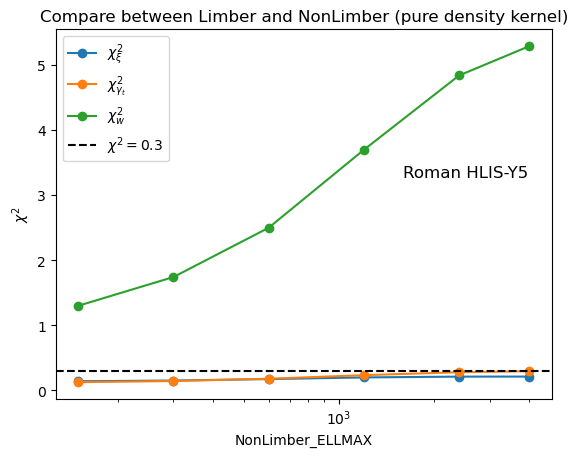

In [34]:
import matplotlib.pyplot as plt

ellmaxs = np.array(ELLMAXS)
chi2_xi = np.array(chi2s[0])
chi2_gammat = np.array(chi2s[1])
chi2_wtheta = np.array(chi2s[2])
plt.plot(ellmaxs, chi2_xi, '-o', label=r'$\chi^2_\xi$')
plt.plot(ellmaxs, chi2_gammat, '-o', label=r'$\chi^2_{\gamma_t}$')
plt.plot(ellmaxs, chi2_wtheta, '-o', label=r'$\chi^2_{w}$')
plt.axhline(y = 0.3, xmin = 0, xmax = 1, c='k', linestyle='--', label=r'$\chi^2=0.3$')
plt.text(x= 0.70, y=0.6, s='Roman HLIS-Y5',transform=plt.gca().transAxes, fontsize=12)
plt.ylabel(r'$\chi^2$')
plt.xlabel('NonLimber_ELLMAX')
plt.xscale('log')
plt.legend()
plt.title('Compare between Limber and NonLimber (pure density kernel)')

### How about Rubin

In [36]:
#load covariance matrix, source and lens sample for DES Y3
cov_file    = './cocoa/Cocoa/projects/lsst_real/data/cov_lsst'
source_file = './cocoa/Cocoa/projects/lsst_real/data/lsst_srcs_4cosmolike.nz'
lens_file   = './cocoa/Cocoa/projects/lsst_real/data/lsst_lens_4cosmolike.nz'

cov_raw = np.loadtxt(cov_file)
ncov = int(np.max(cov_raw[:,0]))+1
cov = np.zeros((ncov, ncov))
for i in range(len(cov_raw)):
    ii = int(cov_raw[i, 0])
    jj = int(cov_raw[i, 1])
    element = cov_raw[i,8] + cov_raw[i,9]
    cov[ii,jj] = element
    cov[jj,ii] = element

srcs_nzs = np.loadtxt(source_file)
lens_nzs = np.loadtxt(lens_file)

z_srcs = srcs_nzs[:,0] + 0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0] + 0.005
lens_nz = lens_nzs[:,1:]

nsrcs = srcs_nz.shape[1]
nlens = lens_nz.shape[1]
ntheta = int(ncov/(nsrcs*(nsrcs+1)+nsrcs*nlens+nlens))

starts = [0, int(nsrcs*(nsrcs+1)*ntheta), int((nsrcs*(nsrcs+1)+nsrcs*nlens)*ntheta), int((nsrcs*(nsrcs+1)+nsrcs*nlens+nlens)*ntheta)]
cov_xi     = cov[starts[0]:starts[1],:][:,starts[0]:starts[1]]
cov_gammat = cov[starts[1]:starts[2],:][:,starts[1]:starts[2]]
cov_wtheta = cov[starts[2]:starts[3],:][:,starts[2]:starts[3]]
invcov_xi     = np.linalg.pinv(cov_xi)
invcov_gammat = np.linalg.pinv(cov_gammat)
invcov_wtheta = np.linalg.pinv(cov_wtheta)

COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

### Limber

In [37]:
# setup lens and source tracer
srcs = []
lens = []
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=False, n_samples=400))

#calculate the power spectrum for calculation of correlation function
ELLMAX_NOLIMBER = 150
logLMIN = np.log(ELLMAX_NOLIMBER)
logLMAX = np.log(60000+1)
NCell = 300
dlogL = (logLMAX - logLMIN)/(NCell - 1)

ells = np.zeros(ELLMAX_NOLIMBER+NCell)
for i in range(ELLMAX_NOLIMBER):
    ells[i] = i
for i in range(NCell):
    ells[i+ELLMAX_NOLIMBER] = np.exp(logLMIN + dlogL*i)
ells = ells[1:]

xi_cl     = []
gammat_cl = []
wtheta_cl = []

for i in range(nsrcs):
    for j in range(i,nsrcs):
        xi_cl.append(ccl.angular_cl(COSMO, srcs[i], srcs[j], ells, l_limber=-1) )

for i in range(nlens):
    for j in range(nsrcs):
        gammat_cl.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, l_limber=-1) )
        
for i in range(nlens):
    wtheta_cl.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, l_limber=-1))
    
#calculate the correlation function
tmin = 1.
tmax = 500.

logtmin = np.log(tmin)
logtmax = np.log(tmax)
logdt=(logtmax - logtmin)/ntheta
fac = (2./3.)
thetas = np.zeros(ntheta)

for i in range(ntheta):
    thetamin = np.exp(logtmin + (i + 0.)*logdt)
    thetamax = np.exp(logtmin + (i + 1.)*logdt)
    thetas[i] = fac * (thetamax**3 - thetamin**3) / (thetamax*thetamax    - thetamin*thetamin)
thetas /= 60

theta_b  = np.geomspace(tmin, tmax, ntheta+1) / 60
theta_u  = theta_b[1:]
theta_l  = theta_b[:-1]

ncombo_xi     = int(nsrcs*(nsrcs+1))
ncombo_gammat = int(nsrcs*nlens)
ncombo_wtheta = int(nlens)

xi, gammat, wtheta = [],[],[]

for i in range(ncombo_xi//2):
    xi.append(correlation_binned(COSMO, ell=ells, C_ell=xi_cl[i], theta_min=theta_l, theta_max=theta_u, type='GG+', method='Legendre'))
for i in range(ncombo_xi//2):
    xi.append(correlation_binned(COSMO, ell=ells, C_ell=xi_cl[i], theta_min=theta_l, theta_max=theta_u, type='GG-', method='Legendre'))
xi = np.concatenate(xi)

for i in range(ncombo_gammat):
    gammat.append(correlation_binned(COSMO, ell=ells, C_ell=gammat_cl[i], theta_min=theta_l, theta_max=theta_u, type='NG', method='Legendre'))
gammat = np.concatenate(gammat)

for i in range(ncombo_wtheta):
    wtheta.append(correlation_binned(COSMO, ell=ells, C_ell=wtheta_cl[i], theta_min=theta_l, theta_max=theta_u, type='NN', method='Legendre'))
wtheta = np.concatenate(wtheta)

limber_noRSD_xi     = xi
limber_noRSD_gammat = gammat
limber_noRSD_wtheta = wtheta

### NoLimber

In [38]:
# setup lens and source tracer
srcs = []
lens = []
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=False, n_samples=400))

#calculate the power spectrum for calculation of correlation function
ELLMAXS = [150, 300, 600, 1200, 2400, 4000]
chi2s = [[],[],[]]
for ELLMAX_NOLIMBER in ELLMAXS:
    #ELLMAX_NOLIMBER = 150
    logLMIN = np.log(ELLMAX_NOLIMBER)
    logLMAX = np.log(60000+1)
    NCell = 300
    dlogL = (logLMAX - logLMIN)/(NCell - 1)
    
    ells = np.zeros(ELLMAX_NOLIMBER+NCell)
    for i in range(ELLMAX_NOLIMBER):
        ells[i] = i
    for i in range(NCell):
        ells[i+ELLMAX_NOLIMBER] = np.exp(logLMIN + dlogL*i)
    ells = ells[1:]
    
    xi_cl     = []
    gammat_cl = []
    wtheta_cl = []
    
    for i in range(nsrcs):
        for j in range(i,nsrcs):
            xi_cl.append(ccl.angular_cl(COSMO, srcs[i], srcs[j], ells, l_limber=ELLMAX_NOLIMBER) )
    
    for i in range(nlens):
        for j in range(nsrcs):
            gammat_cl.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, l_limber=ELLMAX_NOLIMBER) )
            
    for i in range(nlens):
        wtheta_cl.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, l_limber=ELLMAX_NOLIMBER))
        
    #calculate the correlation function
    tmin = 1.
    tmax = 500.
    
    logtmin = np.log(tmin)
    logtmax = np.log(tmax)
    logdt=(logtmax - logtmin)/ntheta
    fac = (2./3.)
    thetas = np.zeros(ntheta)
    
    for i in range(ntheta):
        thetamin = np.exp(logtmin + (i + 0.)*logdt)
        thetamax = np.exp(logtmin + (i + 1.)*logdt)
        thetas[i] = fac * (thetamax**3 - thetamin**3) / (thetamax*thetamax    - thetamin*thetamin)
    thetas /= 60
    
    theta_b  = np.geomspace(tmin, tmax, ntheta+1) / 60
    theta_u  = theta_b[1:]
    theta_l  = theta_b[:-1]
    
    ncombo_xi     = int(nsrcs*(nsrcs+1))
    ncombo_gammat = int(nsrcs*nlens)
    ncombo_wtheta = int(nlens)
    
    xi, gammat, wtheta = [],[],[]
    
    for i in range(ncombo_xi//2):
        xi.append(correlation_binned(COSMO, ell=ells, C_ell=xi_cl[i], theta_min=theta_l, theta_max=theta_u, type='GG+', method='Legendre'))
    for i in range(ncombo_xi//2):
        xi.append(correlation_binned(COSMO, ell=ells, C_ell=xi_cl[i], theta_min=theta_l, theta_max=theta_u, type='GG-', method='Legendre'))
    xi = np.concatenate(xi)
    
    for i in range(ncombo_gammat):
        gammat.append(correlation_binned(COSMO, ell=ells, C_ell=gammat_cl[i], theta_min=theta_l, theta_max=theta_u, type='NG', method='Legendre'))
    gammat = np.concatenate(gammat)
    
    for i in range(ncombo_wtheta):
        wtheta.append(correlation_binned(COSMO, ell=ells, C_ell=wtheta_cl[i], theta_min=theta_l, theta_max=theta_u, type='NN', method='Legendre'))
    wtheta = np.concatenate(wtheta)
    
    nolimber_noRSD_xi     = xi
    nolimber_noRSD_gammat = gammat
    nolimber_noRSD_wtheta = wtheta

    print('just pure density kernel')
    chi2_xi     = (limber_noRSD_xi - nolimber_noRSD_xi)@invcov_xi@(limber_noRSD_xi - nolimber_noRSD_xi)
    chi2s[0].append(chi2_xi)
    print(f'The Limber raises chi2 {chi2_xi:.2f} for xi')
    chi2_gammat = (limber_noRSD_gammat - nolimber_noRSD_gammat)@invcov_gammat@(limber_noRSD_gammat - nolimber_noRSD_gammat)
    print(f'The Limber raises chi2 {chi2_gammat:.2f} for gammat')
    chi2s[1].append(chi2_gammat)
    chi2_wtheta = (limber_noRSD_wtheta - nolimber_noRSD_wtheta)@invcov_wtheta@(limber_noRSD_wtheta - nolimber_noRSD_wtheta)
    print(f'The Limber raises chi2 {chi2_wtheta:.2f} for wtheta')
    chi2s[2].append(chi2_wtheta)

IF_SAVE = True
if IF_SAVE:
    out = np.zeros((4, len(ELLMAXS)))
    out[0] = ELLMAXS
    out[1:] = np.array(chi2s)
    np.savetxt('chi2_nolimber_rubin.txt', out)

/project/chihway/junzhou/Code-comparison/ccl/pyccl/errors.py:22: CCLWarning: Nchi must be a positive integer. Setting to match tracer with large chi samples x 2.
  warnings_builtin.warn(*args, **kwargs)
/project/chihway/junzhou/Code-comparison/ccl/pyccl/errors.py:22: CCLWarning: chi_min must be greater than zero.Setting to default 1e-6 Mpc.
  warnings_builtin.warn(*args, **kwargs)


just pure density kernel
The Limber raises chi2 0.40 for xi
The Limber raises chi2 0.46 for gammat
The Limber raises chi2 7.69 for wtheta
just pure density kernel
The Limber raises chi2 0.43 for xi
The Limber raises chi2 0.54 for gammat
The Limber raises chi2 10.31 for wtheta
just pure density kernel
The Limber raises chi2 0.49 for xi
The Limber raises chi2 0.71 for gammat
The Limber raises chi2 14.80 for wtheta
just pure density kernel
The Limber raises chi2 0.55 for xi
The Limber raises chi2 0.94 for gammat
The Limber raises chi2 21.95 for wtheta
just pure density kernel
The Limber raises chi2 0.57 for xi
The Limber raises chi2 1.11 for gammat
The Limber raises chi2 28.95 for wtheta
just pure density kernel
The Limber raises chi2 0.56 for xi
The Limber raises chi2 1.17 for gammat
The Limber raises chi2 31.89 for wtheta


Text(0.5, 1.0, 'Compare between Limber and NonLimber (pure density kernel)')

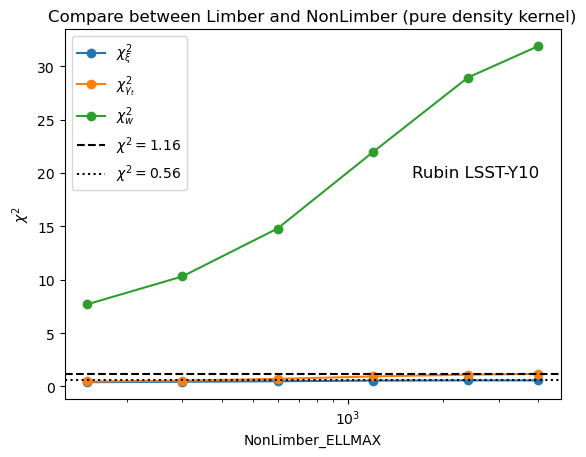

In [46]:
import matplotlib.pyplot as plt

ellmaxs = np.array(ELLMAXS)
chi2_xi = np.array(chi2s[0])
chi2_gammat = np.array(chi2s[1])
chi2_wtheta = np.array(chi2s[2])
plt.plot(ellmaxs, chi2_xi, '-o', label=r'$\chi^2_\xi$')
plt.plot(ellmaxs, chi2_gammat, '-o', label=r'$\chi^2_{\gamma_t}$')
plt.plot(ellmaxs, chi2_wtheta, '-o', label=r'$\chi^2_{w}$')
plt.axhline(y = 1.16, xmin = 0, xmax = 1, c='k', linestyle='--', label=r'$\chi^2=1.16$')
plt.axhline(y = 0.56, xmin = 0, xmax = 1, c='k', linestyle=':', label=r'$\chi^2=0.56$')
plt.text(x= 0.70, y=0.6, s='Rubin LSST-Y10',transform=plt.gca().transAxes, fontsize=12)
plt.ylabel(r'$\chi^2$')
plt.xlabel('NonLimber_ELLMAX')
plt.xscale('log')
plt.legend()
plt.title('Compare between Limber and NonLimber (pure density kernel)')

### Goal 2
Does CCL's NonLimber behaves well when includes RSD?

In [57]:
import numpy as np
import pytest
import pyccl as ccl
from pyccl import CCLWarning

from pyccl.pk2d import Pk2D
from pyccl.correlations import correlation,correlation_binned

#load covariance matrix, source and lens sample for DES Y3
cov_file    = './cocoa/Cocoa/projects/roman_real/data/cov_roman'
source_file = './cocoa/Cocoa/projects/roman_real/data/fiducial.nz'
lens_file   = './cocoa/Cocoa/projects/roman_real/data/lsst_lens_4cosmolike.nz'

cov_raw = np.loadtxt(cov_file)
ncov = int(np.max(cov_raw[:,0]))+1
cov = np.zeros((ncov, ncov))
for i in range(len(cov_raw)):
    ii = int(cov_raw[i, 0])
    jj = int(cov_raw[i, 1])
    element = cov_raw[i,8] + cov_raw[i,9]
    cov[ii,jj] = element
    cov[jj,ii] = element

srcs_nzs = np.loadtxt(source_file)
lens_nzs = np.loadtxt(lens_file)

z_srcs = srcs_nzs[:,0] + 0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0] + 0.005
lens_nz = lens_nzs[:,1:]

nsrcs = srcs_nz.shape[1]
nlens = lens_nz.shape[1]
ntheta = int(ncov/(nsrcs*(nsrcs+1)+nsrcs*nlens+nlens))

starts = [0, int(nsrcs*(nsrcs+1)*ntheta), int((nsrcs*(nsrcs+1)+nsrcs*nlens)*ntheta), int((nsrcs*(nsrcs+1)+nsrcs*nlens+nlens)*ntheta)]
cov_xi     = cov[starts[0]:starts[1],:][:,starts[0]:starts[1]]
cov_gammat = cov[starts[1]:starts[2],:][:,starts[1]:starts[2]]
cov_wtheta = cov[starts[2]:starts[3],:][:,starts[2]:starts[3]]
invcov_xi     = np.linalg.pinv(cov_xi)
invcov_gammat = np.linalg.pinv(cov_gammat)
invcov_wtheta = np.linalg.pinv(cov_wtheta)

COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

### NonLimber RSD

In [58]:
# setup lens and source tracer
srcs = []
lens = []
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=True, n_samples=400))

#calculate the power spectrum for calculation of correlation function
ELLMAX_NOLIMBER = 4000
logLMIN = np.log(20)
logLMAX = np.log(ELLMAX_NOLIMBER)
NCell = 40
dlogL = (logLMAX - logLMIN)/(NCell - 1)

ells = np.zeros(NCell)
for i in range(NCell):
    ells[i] = np.exp(logLMIN + i*dlogL)

nolimber_gammat_cl = ccl.angular_cl(COSMO, lens[nlens-1], srcs[nsrcs-1], ells, l_limber=ELLMAX_NOLIMBER)
nolimber_wtheta_cl = ccl.angular_cl(COSMO, lens[nlens-1], lens[nlens-1], ells, l_limber=ELLMAX_NOLIMBER)


### Limber RSD

In [59]:
# setup lens and source tracer
srcs = []
lens = []
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=True, n_samples=400))

#calculate the power spectrum for calculation of correlation function
ELLMAX_NOLIMBER = 4000
logLMIN = np.log(20)
logLMAX = np.log(ELLMAX_NOLIMBER)
NCell = 40
dlogL = (logLMAX - logLMIN)/(NCell - 1)

ells = np.zeros(NCell)
for i in range(NCell):
    ells[i] = np.exp(logLMIN + i*dlogL)

limber_gammat_cl = ccl.angular_cl(COSMO, lens[nlens-1], srcs[nsrcs-1], ells, l_limber=-1)
limber_wtheta_cl = ccl.angular_cl(COSMO, lens[nlens-1], lens[nlens-1], ells, l_limber=-1)

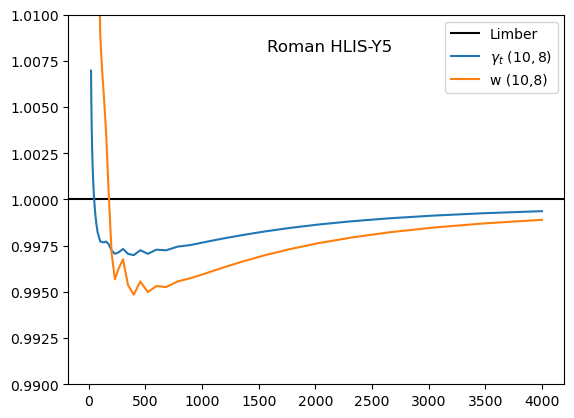

In [75]:
import matplotlib.pyplot as plt

plt.axhline(y = 1, xmin = 0, xmax = 1, c='k', linestyle='-',label='Limber')
plt.plot(ells, (nolimber_gammat_cl/limber_gammat_cl), label = fr'$\gamma_t \ ({nlens},{nsrcs})$')
plt.plot(ells, (nolimber_wtheta_cl/limber_wtheta_cl), label = fr'w ({nlens},{nsrcs})')
plt.ylim(0.99, 1.01)
plt.text(x = 0.4, y = 0.9 ,s = 'Roman HLIS-Y5', transform = plt.gca().transAxes, fontsize=12)
plt.legend()

### CCL actually looks good, how about Cosmolike?

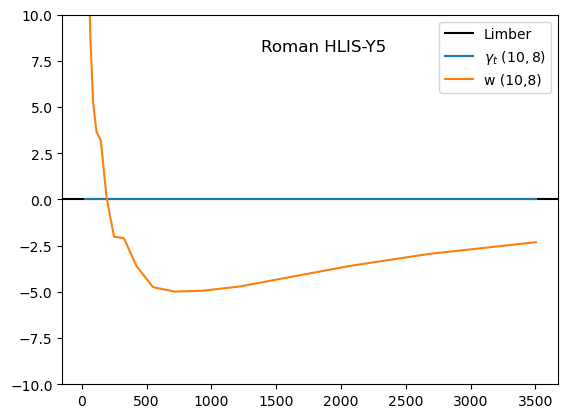

In [53]:
nlens = 10
nsrcs = 8
ncl= 20

cov_file    = './cocoa/Cocoa/projects/roman_fourier/data/cov_roman_fourier'

cov_raw = np.loadtxt(cov_file)
ncov = int(np.max(cov_raw[:,0]))+1
cov = np.zeros((ncov, ncov))
for i in range(len(cov_raw)):
    ii = int(cov_raw[i, 0])
    jj = int(cov_raw[i, 1])
    element = cov_raw[i,8] + cov_raw[i,9]
    cov[ii,jj] = element
    cov[jj,ii] = element

lmin = 20
lmax = 4000
logdl = (np.log(lmax) - np.log(lmin))/ncl
ells = np.zeros(int(ncl))
for i in range(int(ncl)):
    ells[i] = np.exp(np.log(lmin) + (i + 0.5)*logdl)

dv_nolimber = np.loadtxt('./cocoa/Cocoa/projects/roman_fourier/chains/roman_nonlimber_evaluate/roman.modelvector_1')[:,1]
dv_limber = np.loadtxt('./cocoa/Cocoa/projects/roman_fourier/chains/roman_limber_evaluate/roman.modelvector_1')[:,1]
l_g, r_g = int(ncl*(nsrcs*(nsrcs+1)/2 + nlens*nsrcs - 1)), int(ncl*(nsrcs*(nsrcs+1)/2 + nlens*nsrcs))
nolimber_gammat_cl = dv_nolimber[l_g:r_g]
limber_gammat_cl   = dv_limber[l_g:r_g]
cov_gammat_cl = cov[l_g:r_g,:][:,l_g:r_g]
l_w, r_w = int(ncl*(nsrcs*(nsrcs+1)/2 + nlens*nsrcs + nlens - 1)), int(ncl*(nsrcs*(nsrcs+1)/2 + nlens*nsrcs + nlens))
nolimber_wtheta_cl = dv_nolimber[l_w:r_w]
limber_wtheta_cl   = dv_limber[l_w:r_w]
cov_wtheta_cl = cov[l_g:r_g,:][:,l_g:r_g]

import matplotlib.pyplot as plt

plt.axhline(y = 0, xmin = 0, xmax = 1, c='k', linestyle='-',label='Limber')
plt.plot(ells, (nolimber_gammat_cl-limber_gammat_cl)/np.sqrt(np.diag(cov_gammat_cl)), label = fr'$\gamma_t \ ({nlens},{nsrcs})$')
plt.plot(ells, (nolimber_wtheta_cl-limber_wtheta_cl)/np.sqrt(np.diag(cov_wtheta_cl)), label = fr'w ({nlens},{nsrcs})')
plt.ylim(-10, 10)
plt.text(x = 0.4, y = 0.9 ,s = 'Roman HLIS-Y5', transform = plt.gca().transAxes, fontsize=12)
plt.legend()

### This demonstrates that with RSD kernel Limber and NonLimber don't converge even at ell~4000

so let's push ELLMAX_NOLIMBER~4000, and compare them in real space

In [1]:
import numpy as np
import pytest
import pyccl as ccl
from pyccl import CCLWarning

from pyccl.pk2d import Pk2D
from pyccl.correlations import correlation,correlation_binned

In [2]:
#load covariance matrix, source and lens sample for DES Y3
cov_file    = './cocoa/Cocoa/projects/roman_real/data/cov_roman'
source_file = './cocoa/Cocoa/projects/roman_real/data/fiducial.nz'
lens_file   = './cocoa/Cocoa/projects/roman_real/data/lsst_lens_4cosmolike.nz'

cov_raw = np.loadtxt(cov_file)
ncov = int(np.max(cov_raw[:,0]))+1
cov = np.zeros((ncov, ncov))
for i in range(len(cov_raw)):
    ii = int(cov_raw[i, 0])
    jj = int(cov_raw[i, 1])
    element = cov_raw[i,8] + cov_raw[i,9]
    cov[ii,jj] = element
    cov[jj,ii] = element

srcs_nzs = np.loadtxt(source_file)
lens_nzs = np.loadtxt(lens_file)

z_srcs = srcs_nzs[:,0] + 0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0] + 0.005
lens_nz = lens_nzs[:,1:]

nsrcs = srcs_nz.shape[1]
nlens = lens_nz.shape[1]
ntheta = int(ncov/(nsrcs*(nsrcs+1)+nsrcs*nlens+nlens))

starts = [0, int(nsrcs*(nsrcs+1)*ntheta), int((nsrcs*(nsrcs+1)+nsrcs*nlens)*ntheta), int((nsrcs*(nsrcs+1)+nsrcs*nlens+nlens)*ntheta)]
cov_xi     = cov[starts[0]:starts[1],:][:,starts[0]:starts[1]]
cov_gammat = cov[starts[1]:starts[2],:][:,starts[1]:starts[2]]
cov_wtheta = cov[starts[2]:starts[3],:][:,starts[2]:starts[3]]
invcov_xi     = np.linalg.pinv(cov_xi)
invcov_gammat = np.linalg.pinv(cov_gammat)
invcov_wtheta = np.linalg.pinv(cov_wtheta)

COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

### Limber

In [3]:
# setup lens and source tracer
srcs = []
lens = []
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=True, n_samples=400))

#calculate the power spectrum for calculation of correlation function
ELLMAX_NOLIMBER = 150
logLMIN = np.log(ELLMAX_NOLIMBER)
logLMAX = np.log(60000+1)
NCell = 300
dlogL = (logLMAX - logLMIN)/(NCell - 1)

ells = np.zeros(ELLMAX_NOLIMBER+NCell)
for i in range(ELLMAX_NOLIMBER):
    ells[i] = i
for i in range(NCell):
    ells[i+ELLMAX_NOLIMBER] = np.exp(logLMIN + dlogL*i)
ells = ells[1:]

xi_cl     = []
gammat_cl = []
wtheta_cl = []

for i in range(nsrcs):
    for j in range(i,nsrcs):
        xi_cl.append(ccl.angular_cl(COSMO, srcs[i], srcs[j], ells, l_limber=-1) )

for i in range(nlens):
    for j in range(nsrcs):
        gammat_cl.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, l_limber=-1) )
        
for i in range(nlens):
    wtheta_cl.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, l_limber=-1))
    
#calculate the correlation function
tmin = 1.
tmax = 500.

logtmin = np.log(tmin)
logtmax = np.log(tmax)
logdt=(logtmax - logtmin)/ntheta
fac = (2./3.)
thetas = np.zeros(ntheta)

for i in range(ntheta):
    thetamin = np.exp(logtmin + (i + 0.)*logdt)
    thetamax = np.exp(logtmin + (i + 1.)*logdt)
    thetas[i] = fac * (thetamax**3 - thetamin**3) / (thetamax*thetamax    - thetamin*thetamin)
thetas /= 60

theta_b  = np.geomspace(tmin, tmax, ntheta+1) / 60
theta_u  = theta_b[1:]
theta_l  = theta_b[:-1]

ncombo_xi     = int(nsrcs*(nsrcs+1))
ncombo_gammat = int(nsrcs*nlens)
ncombo_wtheta = int(nlens)

gammat, wtheta = [],[]

for i in range(ncombo_gammat):
    gammat.append(correlation_binned(COSMO, ell=ells, C_ell=gammat_cl[i], theta_min=theta_l, theta_max=theta_u, type='NG', method='Legendre'))
gammat = np.concatenate(gammat)

for i in range(ncombo_wtheta):
    wtheta.append(correlation_binned(COSMO, ell=ells, C_ell=wtheta_cl[i], theta_min=theta_l, theta_max=theta_u, type='NN', method='Legendre'))
wtheta = np.concatenate(wtheta)

limber_noRSD_gammat = gammat
limber_noRSD_wtheta = wtheta

### NoLimber

In [6]:
# setup lens and source tracer
srcs = []
lens = []
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=True, n_samples=400))

#calculate the power spectrum for calculation of correlation function
ELLMAXS = [150, 300, 600, 1200, 2400, 4000]
chi2s = [[],[],[]]
for ELLMAX_NOLIMBER in ELLMAXS:
    #ELLMAX_NOLIMBER = 150
    logLMIN = np.log(ELLMAX_NOLIMBER)
    logLMAX = np.log(60000+1)
    NCell = 300
    dlogL = (logLMAX - logLMIN)/(NCell - 1)
    
    ells = np.zeros(ELLMAX_NOLIMBER+NCell)
    for i in range(ELLMAX_NOLIMBER):
        ells[i] = i
    for i in range(NCell):
        ells[i+ELLMAX_NOLIMBER] = np.exp(logLMIN + dlogL*i)
    ells = ells[1:]
    
    gammat_cl = []
    wtheta_cl = []
    
    for i in range(nlens):
        for j in range(nsrcs):
            gammat_cl.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, l_limber=ELLMAX_NOLIMBER) )
            
    for i in range(nlens):
        wtheta_cl.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, l_limber=ELLMAX_NOLIMBER))
        
    #calculate the correlation function
    tmin = 1.
    tmax = 500.
    
    logtmin = np.log(tmin)
    logtmax = np.log(tmax)
    logdt=(logtmax - logtmin)/ntheta
    fac = (2./3.)
    thetas = np.zeros(ntheta)
    
    for i in range(ntheta):
        thetamin = np.exp(logtmin + (i + 0.)*logdt)
        thetamax = np.exp(logtmin + (i + 1.)*logdt)
        thetas[i] = fac * (thetamax**3 - thetamin**3) / (thetamax*thetamax    - thetamin*thetamin)
    thetas /= 60
    
    theta_b  = np.geomspace(tmin, tmax, ntheta+1) / 60
    theta_u  = theta_b[1:]
    theta_l  = theta_b[:-1]
    
    ncombo_xi     = int(nsrcs*(nsrcs+1))
    ncombo_gammat = int(nsrcs*nlens)
    ncombo_wtheta = int(nlens)
    
    gammat, wtheta = [],[]
    
    for i in range(ncombo_gammat):
        gammat.append(correlation_binned(COSMO, ell=ells, C_ell=gammat_cl[i], theta_min=theta_l, theta_max=theta_u, type='NG', method='Legendre'))
    gammat = np.concatenate(gammat)
    
    for i in range(ncombo_wtheta):
        wtheta.append(correlation_binned(COSMO, ell=ells, C_ell=wtheta_cl[i], theta_min=theta_l, theta_max=theta_u, type='NN', method='Legendre'))
    wtheta = np.concatenate(wtheta)
    
    nolimber_noRSD_gammat = gammat
    nolimber_noRSD_wtheta = wtheta

    print('just pure density kernel')
    chi2_gammat = (limber_noRSD_gammat - nolimber_noRSD_gammat)@invcov_gammat@(limber_noRSD_gammat - nolimber_noRSD_gammat)
    print(f'The Limber raises chi2 {chi2_gammat:.2f} for gammat')
    chi2s[0].append(chi2_gammat)
    chi2_wtheta = (limber_noRSD_wtheta - nolimber_noRSD_wtheta)@invcov_wtheta@(limber_noRSD_wtheta - nolimber_noRSD_wtheta)
    print(f'The Limber raises chi2 {chi2_wtheta:.2f} for wtheta')
    chi2s[1].append(chi2_wtheta)

IF_SAVE = False
if IF_SAVE:
    out = np.zeros((3, len(ELLMAXS)))
    out[0] = ELLMAXS
    out[1:] = np.array([chi2s[0],chi2s[1]])
    np.savetxt('chi2_nolimber_RSD_roman.txt', out)

just pure density kernel
The Limber raises chi2 0.11 for gammat
The Limber raises chi2 15.38 for wtheta
just pure density kernel
The Limber raises chi2 0.13 for gammat
The Limber raises chi2 15.53 for wtheta
just pure density kernel
The Limber raises chi2 0.17 for gammat
The Limber raises chi2 16.10 for wtheta
just pure density kernel
The Limber raises chi2 0.22 for gammat
The Limber raises chi2 17.34 for wtheta
just pure density kernel
The Limber raises chi2 0.27 for gammat
The Limber raises chi2 18.65 for wtheta
just pure density kernel
The Limber raises chi2 0.28 for gammat
The Limber raises chi2 19.20 for wtheta


Text(0.5, 1.0, 'Compare between Limber and NonLimber (pure density kernel)')

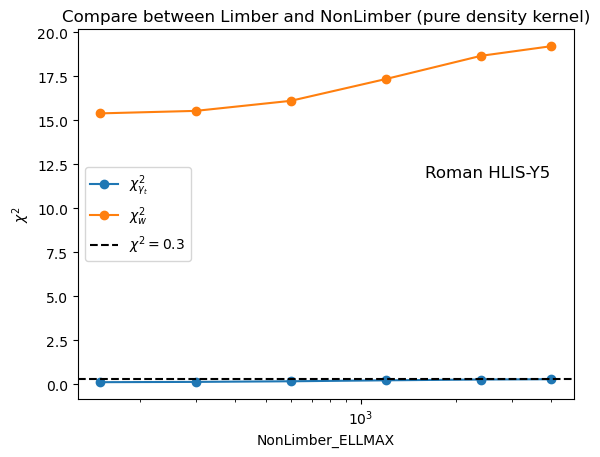

In [7]:
import matplotlib.pyplot as plt

ellmaxs = np.array(ELLMAXS)
chi2_gammat = np.array(chi2s[0])
chi2_wtheta = np.array(chi2s[1])
plt.plot(ellmaxs, chi2_gammat, '-o', label=r'$\chi^2_{\gamma_t}$')
plt.plot(ellmaxs, chi2_wtheta, '-o', label=r'$\chi^2_{w}$')
plt.axhline(y = 0.3, xmin = 0, xmax = 1, c='k', linestyle='--', label=r'$\chi^2=0.3$')
plt.text(x= 0.70, y=0.6, s='Roman HLIS-Y5',transform=plt.gca().transAxes, fontsize=12)
plt.ylabel(r'$\chi^2$')
plt.xlabel('NonLimber_ELLMAX')
plt.xscale('log')
plt.legend()
plt.title('Compare between Limber and NonLimber (pure density kernel)')

### How about Rubin?

In [13]:
#load covariance matrix, source and lens sample for DES Y3
cov_file    = './cocoa/Cocoa/projects/lsst_real/data/cov_lsst'
source_file = './cocoa/Cocoa/projects/lsst_real/data/lsst_srcs_4cosmolike.nz'
lens_file   = './cocoa/Cocoa/projects/lsst_real/data/lsst_lens_4cosmolike.nz'

cov_raw = np.loadtxt(cov_file)
ncov = int(np.max(cov_raw[:,0]))+1
cov = np.zeros((ncov, ncov))
for i in range(len(cov_raw)):
    ii = int(cov_raw[i, 0])
    jj = int(cov_raw[i, 1])
    element = cov_raw[i,8] + cov_raw[i,9]
    cov[ii,jj] = element
    cov[jj,ii] = element

srcs_nzs = np.loadtxt(source_file)
lens_nzs = np.loadtxt(lens_file)

z_srcs = srcs_nzs[:,0] + 0.005
srcs_nz = srcs_nzs[:,1:]
z_lens = lens_nzs[:,0] + 0.005
lens_nz = lens_nzs[:,1:]

nsrcs = srcs_nz.shape[1]
nlens = lens_nz.shape[1]
ntheta = int(ncov/(nsrcs*(nsrcs+1)+nsrcs*nlens+nlens))

starts = [0, int(nsrcs*(nsrcs+1)*ntheta), int((nsrcs*(nsrcs+1)+nsrcs*nlens)*ntheta), int((nsrcs*(nsrcs+1)+nsrcs*nlens+nlens)*ntheta)]
cov_xi     = cov[starts[0]:starts[1],:][:,starts[0]:starts[1]]
cov_gammat = cov[starts[1]:starts[2],:][:,starts[1]:starts[2]]
cov_wtheta = cov[starts[2]:starts[3],:][:,starts[2]:starts[3]]
invcov_xi     = np.linalg.pinv(cov_xi)
invcov_gammat = np.linalg.pinv(cov_gammat)
invcov_wtheta = np.linalg.pinv(cov_wtheta)

COSMO = ccl.Cosmology(
    Omega_c=0.26507647072945384,
    Omega_b=0.0495,
    Omega_k=0,
    h=0.6732,
    w0=-1,
    wa=0,
    A_s=2.1/1e9,
    n_s=0.96605,
    m_nu=0.06,
    Neff=3.046,
    mass_split='single',
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb',
    extra_parameters = {"camb": {"halofit_version": "takahashi",
                                 'AccuracyBoost': 1.0,
                                 'kmax':15,
                                 'dark_energy_model': 'ppf',
                                 'accurate_massive_neutrino_transfer': False,
                                 'k_per_logint': 15,
                                 }}
    )
h=0.6732

### Limber

In [16]:
# setup lens and source tracer
srcs = []
lens = []
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=True, n_samples=400))

#calculate the power spectrum for calculation of correlation function
ELLMAX_NOLIMBER = 150
logLMIN = np.log(ELLMAX_NOLIMBER)
logLMAX = np.log(60000+1)
NCell = 300
dlogL = (logLMAX - logLMIN)/(NCell - 1)

ells = np.zeros(ELLMAX_NOLIMBER+NCell)
for i in range(ELLMAX_NOLIMBER):
    ells[i] = i
for i in range(NCell):
    ells[i+ELLMAX_NOLIMBER] = np.exp(logLMIN + dlogL*i)
ells = ells[1:]

xi_cl     = []
gammat_cl = []
wtheta_cl = []

for i in range(nsrcs):
    for j in range(i,nsrcs):
        xi_cl.append(ccl.angular_cl(COSMO, srcs[i], srcs[j], ells, l_limber=-1) )

for i in range(nlens):
    for j in range(nsrcs):
        gammat_cl.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, l_limber=-1) )
        
for i in range(nlens):
    wtheta_cl.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, l_limber=-1))
    
#calculate the correlation function
tmin = 1.
tmax = 500.

logtmin = np.log(tmin)
logtmax = np.log(tmax)
logdt=(logtmax - logtmin)/ntheta
fac = (2./3.)
thetas = np.zeros(ntheta)

for i in range(ntheta):
    thetamin = np.exp(logtmin + (i + 0.)*logdt)
    thetamax = np.exp(logtmin + (i + 1.)*logdt)
    thetas[i] = fac * (thetamax**3 - thetamin**3) / (thetamax*thetamax    - thetamin*thetamin)
thetas /= 60

theta_b  = np.geomspace(tmin, tmax, ntheta+1) / 60
theta_u  = theta_b[1:]
theta_l  = theta_b[:-1]

ncombo_xi     = int(nsrcs*(nsrcs+1))
ncombo_gammat = int(nsrcs*nlens)
ncombo_wtheta = int(nlens)

gammat, wtheta = [],[]

for i in range(ncombo_gammat):
    gammat.append(correlation_binned(COSMO, ell=ells, C_ell=gammat_cl[i], theta_min=theta_l, theta_max=theta_u, type='NG', method='Legendre'))
gammat = np.concatenate(gammat)

for i in range(ncombo_wtheta):
    wtheta.append(correlation_binned(COSMO, ell=ells, C_ell=wtheta_cl[i], theta_min=theta_l, theta_max=theta_u, type='NN', method='Legendre'))
wtheta = np.concatenate(wtheta)

limber_noRSD_gammat = gammat
limber_noRSD_wtheta = wtheta

### NoLimber

In [17]:
# setup lens and source tracer
srcs = []
lens = []
gbias =  [1.09,1.15,1.21,1.27,1.33,1.40,1.46,1.53,1.60,1.67]

for i in range(nsrcs):
    srcs.append(ccl.WeakLensingTracer(COSMO, dndz=(z_srcs, srcs_nz[:,i]), has_shear=True, n_samples=400))
for i in range(nlens):
    lens.append(ccl.NumberCountsTracer(COSMO, dndz=(z_lens, lens_nz[:,i]), bias=(z_lens,np.ones_like(z_lens)*gbias[i]), has_rsd=True, n_samples=400))

#calculate the power spectrum for calculation of correlation function
ELLMAXS = [150, 300, 600, 1200, 2400, 4000]
chi2s = [[],[],[]]
for ELLMAX_NOLIMBER in ELLMAXS:
    #ELLMAX_NOLIMBER = 150
    logLMIN = np.log(ELLMAX_NOLIMBER)
    logLMAX = np.log(60000+1)
    NCell = 300
    dlogL = (logLMAX - logLMIN)/(NCell - 1)
    
    ells = np.zeros(ELLMAX_NOLIMBER+NCell)
    for i in range(ELLMAX_NOLIMBER):
        ells[i] = i
    for i in range(NCell):
        ells[i+ELLMAX_NOLIMBER] = np.exp(logLMIN + dlogL*i)
    ells = ells[1:]
    
    gammat_cl = []
    wtheta_cl = []
    
    for i in range(nlens):
        for j in range(nsrcs):
            gammat_cl.append(ccl.angular_cl(COSMO, lens[i], srcs[j], ells, l_limber=ELLMAX_NOLIMBER) )
            
    for i in range(nlens):
        wtheta_cl.append(ccl.angular_cl(COSMO, lens[i], lens[i], ells, l_limber=ELLMAX_NOLIMBER))
        
    #calculate the correlation function
    tmin = 1.
    tmax = 500.
    
    logtmin = np.log(tmin)
    logtmax = np.log(tmax)
    logdt=(logtmax - logtmin)/ntheta
    fac = (2./3.)
    thetas = np.zeros(ntheta)
    
    for i in range(ntheta):
        thetamin = np.exp(logtmin + (i + 0.)*logdt)
        thetamax = np.exp(logtmin + (i + 1.)*logdt)
        thetas[i] = fac * (thetamax**3 - thetamin**3) / (thetamax*thetamax    - thetamin*thetamin)
    thetas /= 60
    
    theta_b  = np.geomspace(tmin, tmax, ntheta+1) / 60
    theta_u  = theta_b[1:]
    theta_l  = theta_b[:-1]
    
    ncombo_xi     = int(nsrcs*(nsrcs+1))
    ncombo_gammat = int(nsrcs*nlens)
    ncombo_wtheta = int(nlens)
    
    gammat, wtheta = [],[]
    
    for i in range(ncombo_gammat):
        gammat.append(correlation_binned(COSMO, ell=ells, C_ell=gammat_cl[i], theta_min=theta_l, theta_max=theta_u, type='NG', method='Legendre'))
    gammat = np.concatenate(gammat)
    
    for i in range(ncombo_wtheta):
        wtheta.append(correlation_binned(COSMO, ell=ells, C_ell=wtheta_cl[i], theta_min=theta_l, theta_max=theta_u, type='NN', method='Legendre'))
    wtheta = np.concatenate(wtheta)
    
    nolimber_noRSD_gammat = gammat
    nolimber_noRSD_wtheta = wtheta

    print('just pure density kernel')
    chi2_gammat = (limber_noRSD_gammat - nolimber_noRSD_gammat)@invcov_gammat@(limber_noRSD_gammat - nolimber_noRSD_gammat)
    print(f'The Limber raises chi2 {chi2_gammat:.2f} for gammat')
    chi2s[1].append(chi2_gammat)
    chi2_wtheta = (limber_noRSD_wtheta - nolimber_noRSD_wtheta)@invcov_wtheta@(limber_noRSD_wtheta - nolimber_noRSD_wtheta)
    print(f'The Limber raises chi2 {chi2_wtheta:.2f} for wtheta')
    chi2s[2].append(chi2_wtheta)

IF_SAVE = False
if IF_SAVE:
    out = np.zeros((3, len(ELLMAXS)))
    out[0] = ELLMAXS
    out[1:] = np.array([chi2s[1],chi2s[2]])
    np.savetxt('chi2_nolimber_RSD_rubin.txt', out)

just pure density kernel
The Limber raises chi2 0.50 for gammat
The Limber raises chi2 91.09 for wtheta
just pure density kernel
The Limber raises chi2 0.58 for gammat
The Limber raises chi2 91.93 for wtheta
just pure density kernel
The Limber raises chi2 0.74 for gammat
The Limber raises chi2 95.32 for wtheta
just pure density kernel
The Limber raises chi2 0.97 for gammat
The Limber raises chi2 102.70 for wtheta
just pure density kernel
The Limber raises chi2 1.14 for gammat
The Limber raises chi2 110.72 for wtheta
just pure density kernel
The Limber raises chi2 1.20 for gammat
The Limber raises chi2 114.23 for wtheta


Text(0.5, 1.0, 'Compare between Limber and NonLimber (density kernel + RSD)')

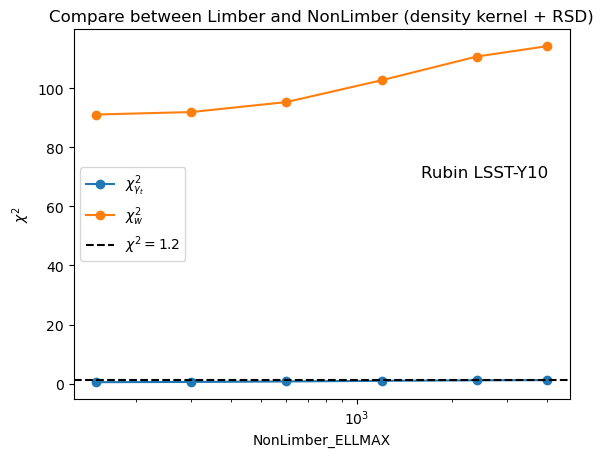

In [23]:
import matplotlib.pyplot as plt

ellmaxs = np.array(ELLMAXS)
chi2_gammat = np.array(chi2s[1])
chi2_wtheta = np.array(chi2s[2])
plt.plot(ellmaxs, chi2_gammat, '-o', label=r'$\chi^2_{\gamma_t}$')
plt.plot(ellmaxs, chi2_wtheta, '-o', label=r'$\chi^2_{w}$')
plt.axhline(y = 1.16, xmin = 0, xmax = 1, c='k', linestyle='--', label=r'$\chi^2=1.2$')
plt.text(x= 0.70, y=0.6, s='Rubin LSST-Y10',transform=plt.gca().transAxes, fontsize=12)
plt.ylabel(r'$\chi^2$')
plt.xlabel('NonLimber_ELLMAX')
plt.xscale('log')
plt.legend()
plt.title('Compare between Limber and NonLimber (density kernel + RSD)')